# Corporate Financial Distress Classification

## Business Problem

Financial distress is an important indicator of a company's financial health and ability to remain financially stable. The objective of this analysis is to use a company's financial information to classify its level of financial distress into three categories: **Healthy, Watch, or Distressed**.

This classification can support early identification of companies that may require closer financial monitoring. In this lab, we will explore the financial characteristics associated with the different distress categories, develop and compare several classification models, evaluate their performance, and identify the features that contribute most to the predictions.

## Dataset

The dataset used is `corporate_financial_distress.csv`. The target variable is `distress_risk_category`, which represents the company's financial distress risk category.

The three target classes are:

* **Healthy** — the company shows relatively strong financial health.
* **Watch** — the company may require monitoring because of potential financial concerns.
* **Distressed** — the company shows stronger indicators of financial difficulty.

## Objective

The main objective is to develop a reliable multiclass classification model that can predict a company's `distress_risk_category` from its financial characteristics while avoiding data leakage and appropriately handling class imbalance.

The analysis will include exploratory data analysis, leakage-safe feature selection and preprocessing, cross-validation, comparison of multiple classification models, diagnostic evaluation, hyperparameter tuning, explainability, and model persistence.


In [ ]:
!git clone https://github.com/GraceChelangat/BI-ClassificationC1.git
%cd BI-ClassificationC1/notebooks

Cloning into 'BI-ClassificationC1'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 21 (delta 7), reused 19 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 555.72 KiB | 34.73 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/BI-ClassificationC1/notebooks/BI-ClassificationC1/notebooks


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
from pathlib import Path

data_path = Path("../data/corporate_financial_distress.csv")

print(data_path.resolve())
print(data_path.exists())

/content/BI-ClassificationC1/notebooks/BI-ClassificationC1/data/corporate_financial_distress.csv
True


In [ ]:
df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (1400, 15)


In [ ]:
df.head()

,company_id,industry_sector,listing_status,credit_rating_band,audit_going_concern_flag,years_in_operation,num_employees,debt_to_equity_ratio,current_ratio,interest_coverage_ratio,revenue_growth_pct,net_profit_margin_pct,working_capital_to_assets_ratio,macroeconomic_interest_rate_pct,distress_risk_category
0,1,Manufacturing,Private,Investment Grade,NaN,6.1,92,1.05,0.65,12.25,8.19,25.440924,-0.025,14.15,Healthy
1,2,Manufacturing,Private,High Risk,NaN,8.9,158,0.24,1.74,7.46,4.55,3.558157,0.139,10.17,Healthy
2,3,Manufacturing,Private,Investment Grade,NaN,39.1,587,2.53,1.32,-0.15,4.15,NaN,0.082,14.42,Healthy
3,4,Energy,Private,Investment Grade,NaN,16.3,49,0.44,2.36,9.51,8.56,-8.063747,0.242,13.41,Healthy
4,5,Manufacturing,Public,Investment Grade,No,9.2,157,1.92,1.56,4.20,2.57,-4.546986,0.039,14.76,Healthy


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   company_id                       1400 non-null   int64  
 1   industry_sector                  1400 non-null   object 
 2   listing_status                   1400 non-null   object 
 3   credit_rating_band               1400 non-null   object 
 4   audit_going_concern_flag         398 non-null    object 
 5   years_in_operation               1400 non-null   float64
 6   num_employees                    1400 non-null   int64  
 7   debt_to_equity_ratio             1400 non-null   float64
 8   current_ratio                    1400 non-null   float64
 9   interest_coverage_ratio          1400 non-null   float64
 10  revenue_growth_pct               1400 non-null   float64
 11  net_profit_margin_pct            1322 non-null   float64
 12  working_capital_to_a

In [ ]:
print("Target variable:", "distress_risk_category")
print("\nClass counts:")
print(df["distress_risk_category"].value_counts())

print("\nClass proportions:")
print(df["distress_risk_category"].value_counts(normalize=True).round(4))

Target variable: distress_risk_category

Class counts:
distress_risk_category
Healthy       980
Watch         280
Distressed    140
Name: count, dtype: int64

Class proportions:
distress_risk_category
Healthy       0.7
Watch         0.2
Distressed    0.1
Name: proportion, dtype: float64


In [ ]:
missing = df.isna().sum()

missing_summary = (
    pd.DataFrame({
        "missing_count": missing,
        "missing_percentage": (missing / len(df) * 100).round(2)
    })
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_percentage
audit_going_concern_flag,1002,71.57
net_profit_margin_pct,78,5.57
industry_sector,0,0.00
listing_status,0,0.00
credit_rating_band,0,0.00
years_in_operation,0,0.00
company_id,0,0.00
num_employees,0,0.00
debt_to_equity_ratio,0,0.00
interest_coverage_ratio,0,0.00


### Initial EDA Findings

The dataset contains **1,400 company observations and 15 variables**. The predictors include categorical business characteristics such as industry sector, listing status, credit rating band, and audit going-concern status, together with numerical financial indicators such as debt-to-equity ratio, current ratio, interest coverage ratio, revenue growth, net profit margin, working capital to assets, and the macroeconomic interest rate.

The target variable, `distress_risk_category`, contains three classes: **Healthy, Watch, and Distressed**. There are 980 Healthy companies (70%), 280 Watch companies (20%), and 140 Distressed companies (10%). This shows a clear class imbalance, with Healthy companies being the majority class and Distressed companies being the minority class. Therefore, accuracy alone will not be sufficient for evaluating the classifiers, and stratified splitting/cross-validation and imbalance-aware evaluation will be important.

Missingness is concentrated in two variables. `audit_going_concern_flag` has **1,002 missing observations (71.57%)**, making missingness itself potentially informative rather than something that should automatically be treated as random. `net_profit_margin_pct` has **78 missing observations (5.57%)**, which is substantially lower and can be considered for conventional numerical imputation after examining its pattern.

The presence of substantial missingness in `audit_going_concern_flag` will require a dataset-specific preprocessing decision. We will investigate whether the missing values represent a structural or meaningful absence of an audit going-concern assessment before selecting the appropriate treatment.


In [ ]:
numeric_columns = df.select_dtypes(include=["number"]).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
company_id,1400.0,700.500000,404.289500,1.000000,350.750000,700.500000,1050.250000,1400.000000
years_in_operation,1400.0,12.199571,8.413296,0.500000,6.075000,10.450000,16.400000,69.400000
num_employees,1400.0,301.251429,221.363333,5.000000,143.000000,247.000000,405.250000,1736.000000
debt_to_equity_ratio,1400.0,1.392471,1.002373,0.050000,0.660000,1.095000,1.930000,7.410000
current_ratio,1400.0,1.623271,0.709583,0.100000,1.120000,1.650000,2.140000,3.870000
interest_coverage_ratio,1400.0,4.488479,5.307081,-11.520000,0.732500,4.580000,8.065000,24.290000
revenue_growth_pct,1400.0,4.149429,8.833111,-23.450000,-1.775000,3.965000,9.865000,29.420000
net_profit_margin_pct,1322.0,5.800128,8.708269,-22.509476,-0.181029,5.638433,11.686121,37.515585
working_capital_to_assets_ratio,1400.0,0.111557,0.139118,-0.262000,0.017000,0.098000,0.197000,0.600000
macroeconomic_interest_rate_pct,1400.0,13.514464,1.981165,6.810000,12.247500,13.520000,14.870000,20.740000


In [ ]:
df[numeric_columns].skew().sort_values(ascending=False)

,0
num_employees,1.551426
years_in_operation,1.496191
debt_to_equity_ratio,1.379204
working_capital_to_assets_ratio,0.383108
net_profit_margin_pct,0.109570
interest_coverage_ratio,0.100725
company_id,0.000000
current_ratio,-0.009371
revenue_growth_pct,-0.012139
macroeconomic_interest_rate_pct,-0.113495


In [ ]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- industry_sector ---
industry_sector
Manufacturing    358
Construction     276
Retail           276
Technology       270
Energy           220
Name: count, dtype: int64

--- listing_status ---
listing_status
Private    1002
Public      398
Name: count, dtype: int64

--- credit_rating_band ---
credit_rating_band
Investment Grade    626
Speculative         509
High Risk           265
Name: count, dtype: int64

--- audit_going_concern_flag ---
audit_going_concern_flag
NaN    1002
No      345
Yes      53
Name: count, dtype: int64

--- distress_risk_category ---
distress_risk_category
Healthy       980
Watch         280
Distressed    140
Name: count, dtype: int64


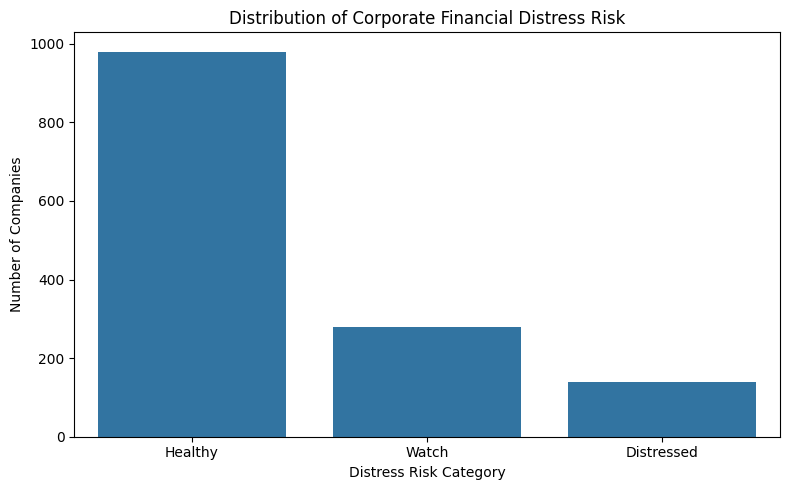

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="distress_risk_category",
    order=["Healthy", "Watch", "Distressed"]
)

plt.title("Distribution of Corporate Financial Distress Risk")
plt.xlabel("Distress Risk Category")
plt.ylabel("Number of Companies")
plt.tight_layout()
plt.show()

### Target Distribution Insight

The target variable is clearly imbalanced. Healthy companies form the majority class with 980 observations (70%), followed by Watch with 280 observations (20%), while Distressed companies are the minority class with only 140 observations (10%). This means a model could achieve high overall accuracy by favoring the Healthy class while performing poorly on financially distressed companies. Therefore, the analysis will use stratified splitting and stratified cross-validation, and model evaluation will include macro-averaged metrics and minority-class diagnostics rather than relying on accuracy alone.

In [ ]:
financial_features = [
    "years_in_operation",
    "num_employees",
    "debt_to_equity_ratio",
    "current_ratio",
    "interest_coverage_ratio",
    "revenue_growth_pct",
    "net_profit_margin_pct",
    "working_capital_to_assets_ratio",
    "macroeconomic_interest_rate_pct"
]

df.groupby("distress_risk_category")[financial_features].mean().round(2)

,years_in_operation,num_employees,debt_to_equity_ratio,current_ratio,interest_coverage_ratio,revenue_growth_pct,net_profit_margin_pct,working_capital_to_assets_ratio,macroeconomic_interest_rate_pct
distress_risk_category,,,,,,,,,
Distressed,12.07,304.36,1.93,1.39,1.64,0.49,1.13,0.07,13.46
Healthy,12.30,301.92,1.23,1.72,5.30,5.19,7.08,0.13,13.50
Watch,11.93,297.34,1.69,1.40,3.07,2.34,3.64,0.07,13.60


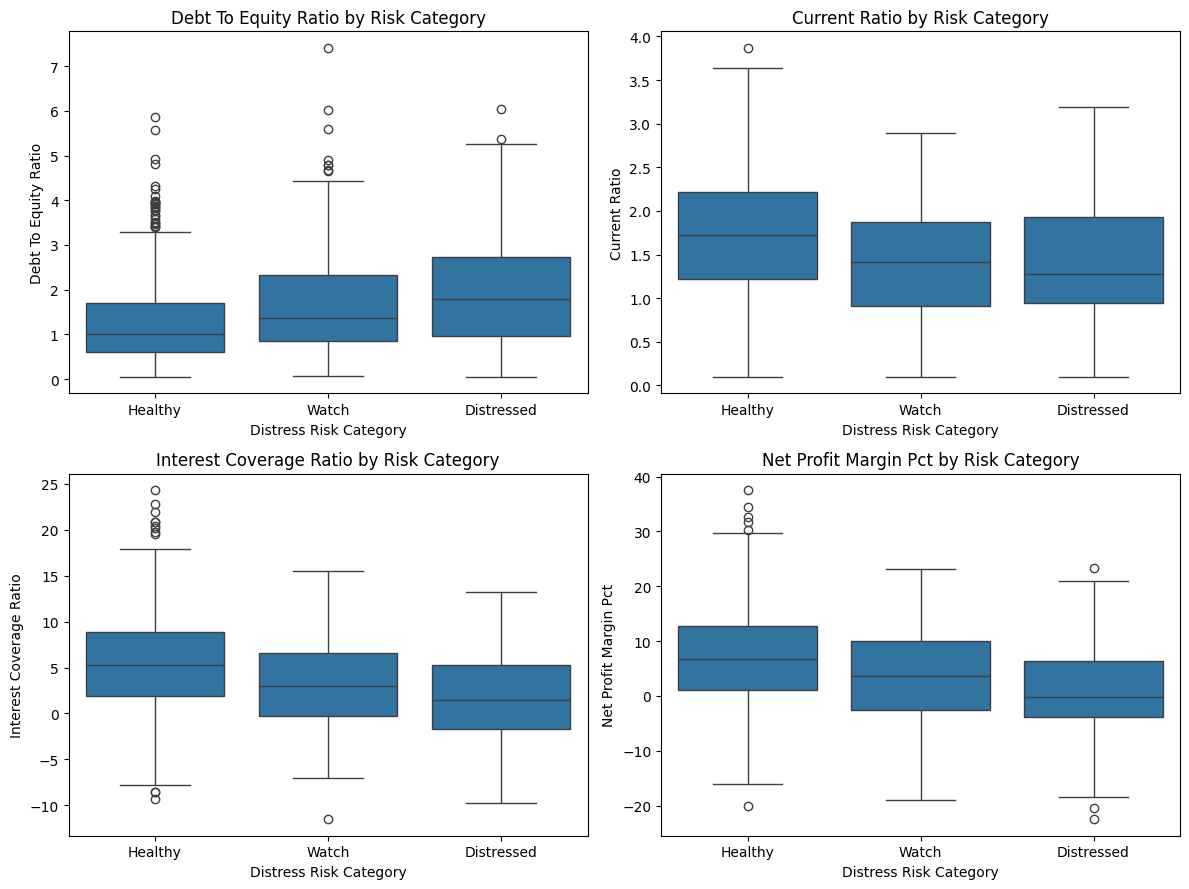

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

features_to_plot = [
    "debt_to_equity_ratio",
    "current_ratio",
    "interest_coverage_ratio",
    "net_profit_margin_pct"
]

for ax, feature in zip(axes.flat, features_to_plot):
    sns.boxplot(
        data=df,
        x="distress_risk_category",
        y=feature,
        order=["Healthy", "Watch", "Distressed"],
        ax=ax
    )
    ax.set_title(f"{feature.replace('_', ' ').title()} by Risk Category")
    ax.set_xlabel("Distress Risk Category")
    ax.set_ylabel(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

In [ ]:
categorical_features = [
    "industry_sector",
    "listing_status",
    "credit_rating_band",
    "audit_going_concern_flag"
]

for feature in categorical_features:
    print(f"\n--- {feature} vs distress risk ---")

    proportions = pd.crosstab(
        df[feature],
        df["distress_risk_category"],
        normalize="index"
    ).round(3)

    display(proportions)


--- industry_sector vs distress risk ---


distress_risk_category,Distressed,Healthy,Watch
industry_sector,,,
Construction,0.123,0.678,0.199
Energy,0.141,0.673,0.186
Manufacturing,0.084,0.726,0.190
Retail,0.112,0.659,0.228
Technology,0.052,0.752,0.196



--- listing_status vs distress risk ---


distress_risk_category,Distressed,Healthy,Watch
listing_status,,,
Private,0.102,0.689,0.210
Public,0.095,0.729,0.176



--- credit_rating_band vs distress risk ---


distress_risk_category,Distressed,Healthy,Watch
credit_rating_band,,,
High Risk,0.181,0.577,0.242
Investment Grade,0.064,0.748,0.188
Speculative,0.102,0.705,0.193



--- audit_going_concern_flag vs distress risk ---


distress_risk_category,Distressed,Healthy,Watch
audit_going_concern_flag,,,
No,0.096,0.716,0.188
Yes,0.094,0.811,0.094


In [ ]:
pd.crosstab(
    df["audit_going_concern_flag"].isna(),
    df["distress_risk_category"],
    normalize="index"
).round(3)

distress_risk_category,Distressed,Healthy,Watch
audit_going_concern_flag,,,
False,0.095,0.729,0.176
True,0.102,0.689,0.210


### Categorical Features and Financial Distress

The industry distribution shows some differences in distress risk across sectors. Energy has the highest proportion of Distressed companies at 14.1%, while Technology has the lowest at 5.2%. Retail has the highest Watch proportion at 22.8%. This suggests that industry sector may contain useful information for distinguishing financial distress categories.

Listing status shows a smaller difference. Public companies have a higher Healthy proportion (72.9%) than Private companies (68.9%), while Private companies have a higher Watch proportion (21.0%) than Public companies (17.6%). The Distressed proportions are relatively similar at 9.5% for Public companies and 10.2% for Private companies.

Credit rating shows the clearest relationship with distress risk. Companies in the High Risk credit-rating band have the highest Distressed proportion (18.1%) and Watch proportion (24.2%), while only 57.7% are Healthy. In comparison, Investment Grade companies are 74.8% Healthy and only 6.4% Distressed. This suggests that credit rating is likely to be an important predictor of financial distress.

The observed audit going-concern flag also shows a relationship with the target. Companies with a recorded "Yes" flag are 81.1% Healthy, compared with 71.6% for companies with a recorded "No" flag. However, because 71.57% of the audit flag values are missing, these observed categories represent only a minority of the dataset. Therefore, the missingness pattern must be investigated before deciding how to encode this variable.

The missingness analysis shows that companies with a missing audit going-concern flag are 68.9% Healthy, 21.0% Watch, and 10.2% Distressed, while companies with a recorded flag are 72.9% Healthy, 17.6% Watch, and 9.5% Distressed. The difference suggests that missingness may contain some information about the target, although the relationship is not extremely large. We will therefore investigate whether the missingness is structural before preprocessing.

In [ ]:
pd.crosstab(
    df["audit_going_concern_flag"].isna(),
    df["listing_status"],
    normalize="index"
).round(3)

listing_status,Private,Public
audit_going_concern_flag,,
False,0.0,1.0
True,1.0,0.0


In [ ]:
pd.crosstab(
    df["audit_going_concern_flag"].isna(),
    df["credit_rating_band"],
    normalize="index"
).round(3)

credit_rating_band,High Risk,Investment Grade,Speculative
audit_going_concern_flag,,,
False,0.186,0.437,0.377
True,0.191,0.451,0.358


In [ ]:
pd.crosstab(
    df["audit_going_concern_flag"].isna(),
    df["industry_sector"],
    normalize="index"
).round(3)

industry_sector,Construction,Energy,Manufacturing,Retail,Technology
audit_going_concern_flag,,,,,
False,0.181,0.163,0.251,0.209,0.196
True,0.204,0.155,0.257,0.193,0.192


In [ ]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
company_id,1400.0,700.500000,404.289500,1.000000,350.750000,700.500000,1050.250000,1400.000000
years_in_operation,1400.0,12.199571,8.413296,0.500000,6.075000,10.450000,16.400000,69.400000
num_employees,1400.0,301.251429,221.363333,5.000000,143.000000,247.000000,405.250000,1736.000000
debt_to_equity_ratio,1400.0,1.392471,1.002373,0.050000,0.660000,1.095000,1.930000,7.410000
current_ratio,1400.0,1.623271,0.709583,0.100000,1.120000,1.650000,2.140000,3.870000
interest_coverage_ratio,1400.0,4.488479,5.307081,-11.520000,0.732500,4.580000,8.065000,24.290000
revenue_growth_pct,1400.0,4.149429,8.833111,-23.450000,-1.775000,3.965000,9.865000,29.420000
net_profit_margin_pct,1322.0,5.800128,8.708269,-22.509476,-0.181029,5.638433,11.686121,37.515585
working_capital_to_assets_ratio,1400.0,0.111557,0.139118,-0.262000,0.017000,0.098000,0.197000,0.600000
macroeconomic_interest_rate_pct,1400.0,13.514464,1.981165,6.810000,12.247500,13.520000,14.870000,20.740000


In [ ]:
df[numeric_columns].skew().sort_values(ascending=False)

,0
num_employees,1.551426
years_in_operation,1.496191
debt_to_equity_ratio,1.379204
working_capital_to_assets_ratio,0.383108
net_profit_margin_pct,0.109570
interest_coverage_ratio,0.100725
company_id,0.000000
current_ratio,-0.009371
revenue_growth_pct,-0.012139
macroeconomic_interest_rate_pct,-0.113495


In [ ]:
# Check for outliers using the IQR method

Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

outlier_counts = (
    ((df[numeric_columns] < (Q1 - 1.5 * IQR)) |
     (df[numeric_columns] > (Q3 + 1.5 * IQR)))
    .sum()
)

outlier_counts.sort_values(ascending=False)

,0
num_employees,50
years_in_operation,40
debt_to_equity_ratio,38
working_capital_to_assets_ratio,23
macroeconomic_interest_rate_pct,21
revenue_growth_pct,16
net_profit_margin_pct,11
interest_coverage_ratio,10
current_ratio,1
company_id,0


### Outlier Analysis

The Interquartile Range (IQR) method was used to identify potential outliers in the numerical variables. The results show that `num_employees` had the highest number of potential outliers (50), followed by `years_in_operation` (40) and `debt_to_equity_ratio` (38). Other variables such as `working_capital_to_assets_ratio`, `macroeconomic_interest_rate_pct`, and `revenue_growth_pct` also contained some potential outliers.

The presence of these observations is consistent with the earlier skewness analysis, particularly for `num_employees`, `years_in_operation`, and `debt_to_equity_ratio`. However, the identified outliers will not be automatically removed because extreme values in financial data may represent genuine business conditions rather than errors.

Therefore, the outliers will be retained initially and appropriate preprocessing or scaling techniques will be considered during model development.

In [ ]:
# Compare numerical variables across distress risk categories

df.groupby("distress_risk_category")[numeric_columns].median().T.round(2)

distress_risk_category,Distressed,Healthy,Watch
company_id,747.00,700.50,680.00
years_in_operation,10.05,10.60,9.90
num_employees,242.50,248.00,245.50
debt_to_equity_ratio,1.80,1.00,1.37
current_ratio,1.27,1.72,1.42
interest_coverage_ratio,1.46,5.25,2.97
revenue_growth_pct,0.91,5.00,2.56
net_profit_margin_pct,-0.18,6.69,3.64
working_capital_to_assets_ratio,0.06,0.12,0.06
macroeconomic_interest_rate_pct,13.43,13.51,13.66


In [ ]:
# Compare the mean values across distress risk categories

df.groupby("distress_risk_category")[numeric_columns].mean().T.round(2)

distress_risk_category,Distressed,Healthy,Watch
company_id,728.95,698.64,692.78
years_in_operation,12.07,12.30,11.93
num_employees,304.36,301.92,297.34
debt_to_equity_ratio,1.93,1.23,1.69
current_ratio,1.39,1.72,1.40
interest_coverage_ratio,1.64,5.30,3.07
revenue_growth_pct,0.49,5.19,2.34
net_profit_margin_pct,1.13,7.08,3.64
working_capital_to_assets_ratio,0.07,0.13,0.07
macroeconomic_interest_rate_pct,13.46,13.50,13.60


### Numerical Variables by Distress Risk Category

The mean and median values of the numerical variables were compared across the `Distressed`, `Healthy`, and `Watch` categories to identify patterns associated with financial distress.

The results show clear differences in several financial indicators. `Distressed` companies have a higher median debt-to-equity ratio (1.80) compared with `Healthy` companies (1.00), indicating relatively higher financial leverage. They also have a lower median current ratio (1.27) compared with `Healthy` companies (1.72), suggesting weaker short-term liquidity.

The interest coverage ratio shows an even stronger pattern. The median is 1.46 for `Distressed` companies compared with 5.25 for `Healthy` companies. This suggests that distressed companies generally have less ability to cover their interest obligations.

Similarly, `Distressed` companies have lower median revenue growth (0.91%) and net profit margin (-0.18%) compared with `Healthy` companies, which have median values of 5.00% and 6.69%, respectively. This indicates weaker growth and profitability among distressed companies.

The working capital to assets ratio is also lower for `Distressed` and `Watch` companies (0.06) than for `Healthy` companies (0.12), suggesting weaker working capital positions.

In contrast, `years_in_operation`, `num_employees`, and `macroeconomic_interest_rate_pct` show relatively small differences across the three categories. This suggests that these variables may have weaker relationships with financial distress compared with the financial-ratio variables.

Overall, the analysis suggests that leverage, liquidity, interest coverage, revenue growth, profitability, and working capital are potentially important predictors of financial distress. These relationships will be investigated further during correlation analysis and model development.

### Correlation Analysis

Correlation analysis is performed to examine the strength and direction of relationships between the numerical variables. This helps identify highly correlated predictors and potential multicollinearity before building the classification models.

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df[numeric_columns].corr().round(2)

correlation_matrix

,company_id,years_in_operation,num_employees,debt_to_equity_ratio,current_ratio,interest_coverage_ratio,revenue_growth_pct,net_profit_margin_pct,working_capital_to_assets_ratio,macroeconomic_interest_rate_pct
company_id,1.00,0.05,-0.01,0.01,0.02,0.00,-0.03,-0.01,0.03,-0.00
years_in_operation,0.05,1.00,0.01,-0.01,0.05,-0.03,-0.02,-0.06,0.01,-0.02
num_employees,-0.01,0.01,1.00,0.03,0.03,0.00,-0.00,-0.01,0.02,-0.02
debt_to_equity_ratio,0.01,-0.01,0.03,1.00,-0.00,0.03,0.02,-0.02,0.00,-0.05
current_ratio,0.02,0.05,0.03,-0.00,1.00,0.02,0.00,-0.01,0.91,-0.01
interest_coverage_ratio,0.00,-0.03,0.00,0.03,0.02,1.00,-0.00,0.02,0.00,0.00
revenue_growth_pct,-0.03,-0.02,-0.00,0.02,0.00,-0.00,1.00,0.02,0.01,0.01
net_profit_margin_pct,-0.01,-0.06,-0.01,-0.02,-0.01,0.02,0.02,1.00,-0.02,0.00
working_capital_to_assets_ratio,0.03,0.01,0.02,0.00,0.91,0.00,0.01,-0.02,1.00,0.01
macroeconomic_interest_rate_pct,-0.00,-0.02,-0.02,-0.05,-0.01,0.00,0.01,0.00,0.01,1.00


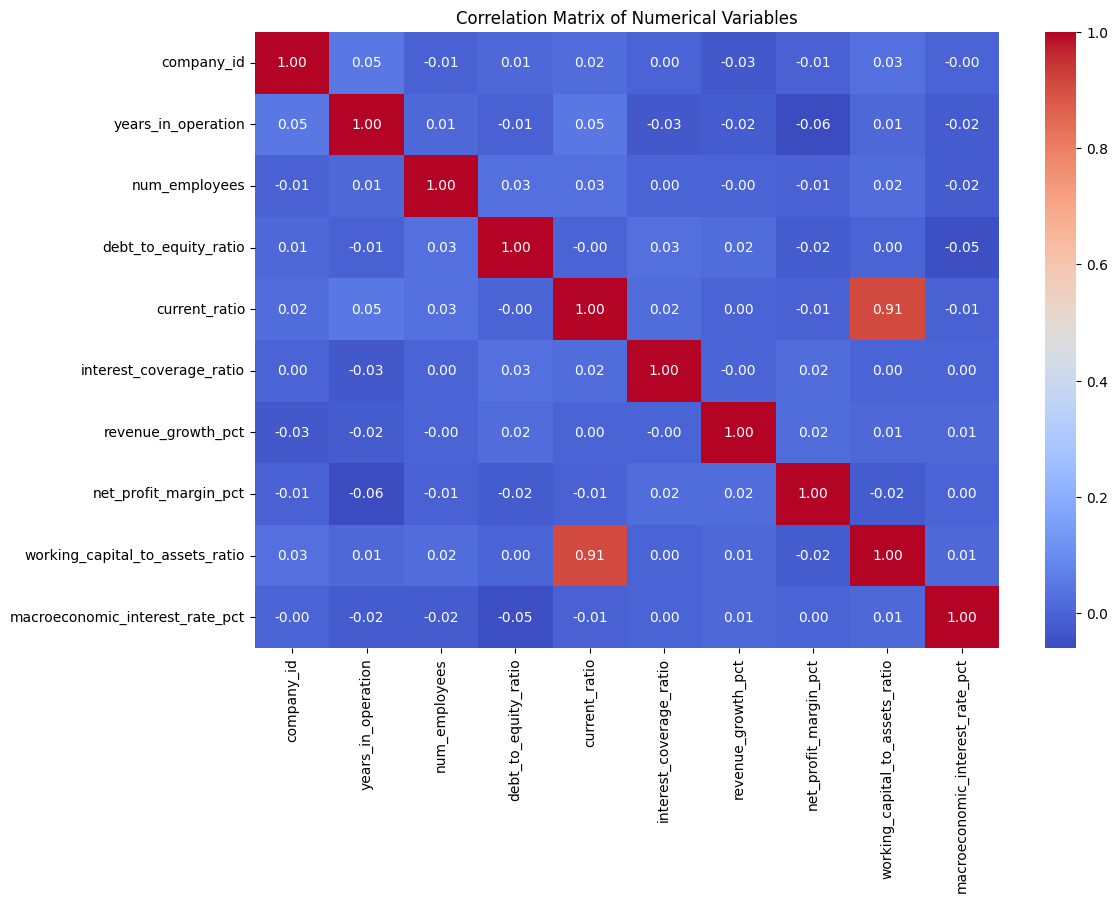

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Correlation Analysis Interpretation

The correlation matrix shows that most numerical variables have weak linear relationships with one another, with correlation coefficients generally close to zero.

However, a strong positive correlation of 0.91 was observed between `current_ratio` and `working_capital_to_assets_ratio`. This indicates potential multicollinearity because the two variables may contain overlapping information. This relationship will be considered during feature selection and preprocessing to avoid unnecessary redundancy in the classification models.

The remaining numerical predictors do not show strong pairwise correlations, suggesting that severe multicollinearity is not widespread in the dataset.

The `company_id` variable has very weak correlations with the other numerical variables and represents an identification number rather than a meaningful business characteristic. Therefore, it should be excluded from the predictive features during model preparation.

## EDA Summary

The exploratory data analysis provided several important insights into the dataset.

- The dataset contains **1,400 companies** across three financial distress categories: `Healthy` (70%), `Watch` (20%), and `Distressed` (10%). This indicates class imbalance, which should be considered when training and evaluating the classification models.
- `net_profit_margin_pct` contains missing values, while the missingness analysis for `audit_going_concern_flag` showed relatively similar distributions across credit rating bands and industry sectors.
- The numerical analysis identified right-skewness in `num_employees`, `years_in_operation`, and `debt_to_equity_ratio`.
- The IQR analysis identified potential outliers in several numerical variables. These observations will be retained initially because extreme financial values may represent genuine business conditions.
- Distressed companies generally showed higher debt-to-equity ratios and lower current ratios, interest coverage ratios, revenue growth, profitability, and working capital relative to healthy companies.
- The correlation analysis found a strong positive correlation (0.91) between `current_ratio` and `working_capital_to_assets_ratio`, indicating potential multicollinearity.
- `company_id` is an identifier and does not represent a meaningful business characteristic, so it should not be used as a predictive feature.
- The perfect relationship observed between `listing_status` and `audit_going_concern_flag` requires careful consideration because it may result in perfect separation or data leakage depending on how the variables relate to the target.

Based on these findings, the next stage is to prepare the data for classification modeling through feature selection, missing-value treatment, categorical encoding, train-test splitting, scaling where necessary, and class-imbalance handling.

In [ ]:
# Define the target variable
target = "distress_risk_category"

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1400, 14)
Target shape: (1400,)


### Separating Features and Target

The dataset is divided into two components: the predictor variables (`X`) and the target variable (`y`). The target variable is `distress_risk_category`, which contains the three classes that the classification models will predict: `Healthy`, `Watch`, and `Distressed`.

All remaining variables initially form the predictor set. Further feature selection and preprocessing will be performed before model training.

In [ ]:
# Remove company_id because it is an identifier, not a predictive feature
X = X.drop(columns=["company_id"])

# Identify numerical features
numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

# Identify categorical features
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of features:", X.shape[1])

Numerical features:
['years_in_operation', 'num_employees', 'debt_to_equity_ratio', 'current_ratio', 'interest_coverage_ratio', 'revenue_growth_pct', 'net_profit_margin_pct', 'working_capital_to_assets_ratio', 'macroeconomic_interest_rate_pct']

Categorical features:
['industry_sector', 'listing_status', 'credit_rating_band', 'audit_going_concern_flag']

Number of features: 13


### Removing Identifier Variable

The `company_id` variable was removed from the predictor set because it is an identification number rather than a meaningful business characteristic. Including an identifier could cause the model to learn arbitrary patterns associated with company numbering rather than genuine financial or business relationships.

After removing `company_id`, the dataset contains 13 predictor variables consisting of numerical and categorical features.

In [ ]:
!pip install scikit-learn

## Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# split BEFORE fitting any feature selector, encoder, imputer, or scaler.
# Fitting any of those on the full 1,400 rows first would let information
# from rows that should be "unseen" leak into our modelling decisions.

# We stratify on the target because the EDA above found a 70/20/10 class
# split (Healthy/Watch/Distressed). Distressed has only 140 rows in the
# whole dataset, so a plain random split could easily under- or over-
# represent it in the test set by chance. Stratification keeps both splits
# at the same ~70/20/10 ratio.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,   # 80/20: with only 1,400 rows total, 20% (280 rows,
                       # ~28 Distressed) is the smallest test set we're
                       # comfortable evaluating the minority class on
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 1120 rows
Test set: 280 rows

Training class proportions:
distress_risk_category
Healthy       0.7
Watch         0.2
Distressed    0.1
Name: proportion, dtype: float64

Test class proportions:
distress_risk_category
Healthy       0.7
Watch         0.2
Distressed    0.1
Name: proportion, dtype: float64


In [ ]:
## Re-derive numeric/categorical feature lists from the TRAINING split
# Specifically, so nothing here is influenced by test-set values

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['years_in_operation', 'num_employees', 'debt_to_equity_ratio', 'current_ratio', 'interest_coverage_ratio', 'revenue_growth_pct', 'net_profit_margin_pct', 'working_capital_to_assets_ratio', 'macroeconomic_interest_rate_pct']
Categorical features: ['industry_sector', 'listing_status', 'credit_rating_band', 'audit_going_concern_flag']


In [ ]:
# ANOVA F-test and Mutual Information for feature selection
from sklearn.feature_selection import f_classif, mutual_info_classif
numeric_train_filled = X_train[numeric_features].fillna(X_train[numeric_features].median())

f_stats, p_values = f_classif(numeric_train_filled, y_train)
mi_scores = mutual_info_classif(numeric_train_filled, y_train, random_state=42)

numeric_selection = pd.DataFrame({
    "feature": numeric_features,
    "ANOVA_F": f_stats,
    "p_value": p_values,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

numeric_selection.round(4)

,feature,ANOVA_F,p_value,mutual_info
6,net_profit_margin_pct,34.4424,0.0000,0.0474
2,debt_to_equity_ratio,43.3313,0.0000,0.0417
4,interest_coverage_ratio,38.6754,0.0000,0.0395
5,revenue_growth_pct,19.4621,0.0000,0.0380
3,current_ratio,29.6045,0.0000,0.0309
7,working_capital_to_assets_ratio,24.8149,0.0000,0.0261
1,num_employees,0.2859,0.7514,0.0187
0,years_in_operation,0.5290,0.5893,0.0047
8,macroeconomic_interest_rate_pct,0.0045,0.9955,0.0000


In [ ]:
# Chi - square test for categorical feature selection
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

# audit_going_concern_flag is 71.57% missing — the EDA showed this is
# STRUCTURAL (only recorded for Public companies), not random. We fill the
# gap with an explicit "Not Recorded" category rather than most-frequent,
# so this test can still detect the missingness pattern itself.
categorical_train = X_train[categorical_features].copy()
categorical_train["audit_going_concern_flag"] = categorical_train["audit_going_concern_flag"].fillna("Not Recorded")

categorical_train_encoded = categorical_train.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))

chi2_stats, chi2_p = chi2(categorical_train_encoded, y_train)
categorical_selection = pd.DataFrame({
    "feature": categorical_features,
    "chi2_statistic": chi2_stats,
    "p_value": chi2_p
}).sort_values("chi2_statistic", ascending=False)

categorical_selection.round(4)

,feature,chi2_statistic,p_value
0,industry_sector,4.8617,0.0880
2,credit_rating_band,3.7109,0.1564
1,listing_status,0.8410,0.6567
3,audit_going_concern_flag,0.1252,0.9393


In [ ]:
# Cross Check
from scipy import stats as scipy_stats

def cramers_v(confusion_matrix):
    chi2_stat = scipy_stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2_stat / n
    r, k = confusion_matrix.shape

    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corrected / min(k_corrected - 1, r_corrected - 1))

cramers_results = {}
for col in categorical_features:
    contingency = pd.crosstab(categorical_train[col], y_train)
    cramers_results[col] = cramers_v(contingency.values)

cramers_df = pd.DataFrame.from_dict(
    cramers_results, orient="index", columns=["Cramers_V"]
).sort_values("Cramers_V", ascending=False)

cramers_df.round(4)

,Cramers_V
credit_rating_band,0.1049
industry_sector,0.0382
listing_status,0.0000
audit_going_concern_flag,0.0000


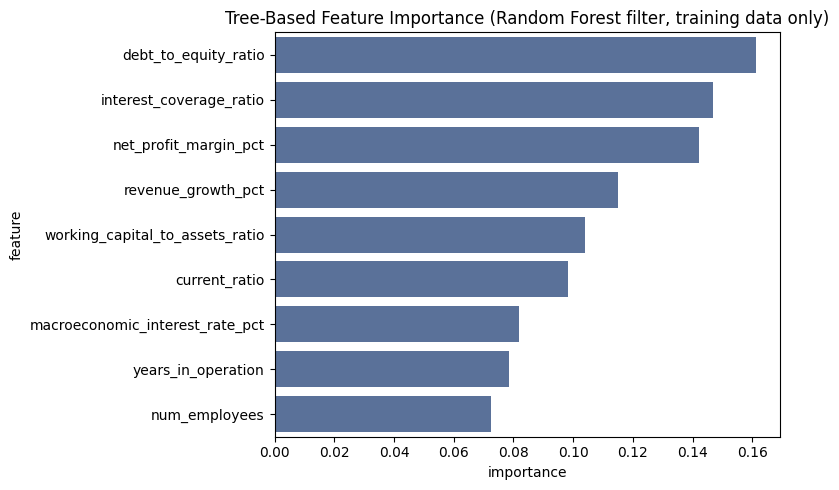

,feature,importance
2,debt_to_equity_ratio,0.1612
4,interest_coverage_ratio,0.1468
6,net_profit_margin_pct,0.1420
5,revenue_growth_pct,0.1149
7,working_capital_to_assets_ratio,0.1039
3,current_ratio,0.0984
8,macroeconomic_interest_rate_pct,0.0820
0,years_in_operation,0.0785
1,num_employees,0.0723


In [ ]:
# Tree-based Importance Filter
from sklearn.ensemble import RandomForestClassifier

#Unlike ANOVA, this can pick up non-linear relationships
# and interactions — used here to double-check the numeric features ANOVA/MI
# flagged as weak before deciding to drop them for any model family.
rf_filter = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
rf_filter.fit(numeric_train_filled, y_train)

tree_importance = pd.DataFrame({
    "feature": numeric_features,
    "importance": rf_filter.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=tree_importance, y="feature", x="importance", color="#4F6EA4")
plt.title("Tree-Based Feature Importance (Random Forest filter, training data only)")
plt.tight_layout()
plt.show()

tree_importance.round(4)

In [ ]:
# Multiccollinearity check
# The EDA found current_ratio and working_capital_to_assets_ratio correlated
# at 0.91 on the FULL dataset. Re-checking on the training split only, since
# that's the data the models will actually learn from.
print("Correlation (training set only):")
print(X_train[["current_ratio", "working_capital_to_assets_ratio"]].corr().round(3))

Correlation (training set only):
                                 current_ratio  \
current_ratio                            1.000   
working_capital_to_assets_ratio          0.915   

                                 working_capital_to_assets_ratio  
current_ratio                                              0.915  
working_capital_to_assets_ratio                            1.000  


In [ ]:
selected_features_linear = [
    c for c in X_train.columns
    if c not in ["working_capital_to_assets_ratio", "num_employees",
                 "years_in_operation", "macroeconomic_interest_rate_pct"]
]
selected_features_tree = list(X_train.columns)

print("Linear/distance-based model feature set:", selected_features_linear)
print("Tree-based model feature set:", selected_features_tree)

Linear/distance-based model feature set: ['industry_sector', 'listing_status', 'credit_rating_band', 'audit_going_concern_flag', 'debt_to_equity_ratio', 'current_ratio', 'interest_coverage_ratio', 'revenue_growth_pct', 'net_profit_margin_pct']
Tree-based model feature set: ['industry_sector', 'listing_status', 'credit_rating_band', 'audit_going_concern_flag', 'years_in_operation', 'num_employees', 'debt_to_equity_ratio', 'current_ratio', 'interest_coverage_ratio', 'revenue_growth_pct', 'net_profit_margin_pct', 'working_capital_to_assets_ratio', 'macroeconomic_interest_rate_pct']


### Final Feature Selection Decision

Feature selection was performed using ANOVA F-test, Mutual Information, Chi-square/Cramer's V, Random Forest importance, and a multicollinearity check, using the training data only.

For **linear/distance-based models**, we dropped:
- `working_capital_to_assets_ratio` because it is highly correlated with `current_ratio` (r = 0.915), and `current_ratio` had stronger ANOVA and Mutual Information scores.
- `num_employees`, `years_in_operation`, and `macroeconomic_interest_rate_pct` because they showed very weak univariate signal, with high p-values and low Mutual Information.

For **tree-based models** (Random Forest), all features were retained because tree models can handle correlated features and `macroeconomic_interest_rate_pct` showed useful tree-based importance.

`company_id` was excluded because it is only an identifier and does not provide meaningful predictive information. All four categorical features were retained for preprocessing because some may provide useful information through their categories or missingness patterns.

## Preprocessing Pipeline
### Member 3: Encoding, Imputation, Scaling and Class-Imbalance Handling

This section prepares the selected features for modelling. All preprocessing is done using the training data only to avoid data leakage. Two pipelines are used: one for linear/distance-based models and another for tree-based models.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [ ]:
# Re-verify the missingness structure on the TRAINING split specifically.
# The EDA established these patterns on the full dataset before the split
# existed; here we confirm they still hold on X_train since that's the
# only data our imputers are allowed to learn from.

print("audit_going_concern_flag missingness vs listing_status (train only):")
print(pd.crosstab(
    X_train["audit_going_concern_flag"].isna(),
    X_train["listing_status"]
))

print("\nnet_profit_margin_pct missingness vs target class (train only):")
print(pd.crosstab(
    X_train["net_profit_margin_pct"].isna(),
    y_train,
    normalize="index"
).round(3))

audit_going_concern_flag missingness vs listing_status (train only):
listing_status            Private  Public
audit_going_concern_flag                 
False                           0     318
True                          802       0

net_profit_margin_pct missingness vs target class (train only):
distress_risk_category  Distressed  Healthy  Watch
net_profit_margin_pct                             
False                        0.097    0.700  0.203
True                         0.149    0.701  0.149


### Distinguishing Structural vs. Random Missingness

The two variables have different missing-value patterns:

- **`audit_going_concern_flag`** is missing for all Private companies but available for all Public companies. This is structural missingness so `"Not Recorded"` is used instead of removing the information.

- **`net_profit_margin_pct`** does not show a strong missing-value pattern across the classes. It is treated as random missingness and filled using the median.

Therefore the two variables are handled differently in the preprocessing pipeline.

In [ ]:
numeric_features_linear = [c for c in selected_features_linear if c in numeric_features]
numeric_features_tree = [c for c in selected_features_tree if c in numeric_features]

In [ ]:
print(pd.crosstab(X_train["credit_rating_band"], y_train, normalize="index").round(3))

distress_risk_category  Distressed  Healthy  Watch
credit_rating_band                                
High Risk                    0.190    0.592  0.218
Investment Grade             0.064    0.739  0.196
Speculative                  0.099    0.706  0.195


In [ ]:
audit_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Not Recorded")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

### Encoding Decisions

- **`credit_rating_band` → Ordinal encoding:** The ratings have a clear order from Investment Grade to High Risk so they are encoded as 0, 1 and 2.

- **`industry_sector` and `listing_status` → One-hot encoding:** These categories have no natural order so one-hot encoding is used.

- **`audit_going_concern_flag` → One-hot encoding:** Missing values are replaced with `"Not Recorded"` because the missingness is meaningful. This keeps the information for Public companies without assigning incorrect Yes/No values.

The `"Not Recorded"` category is related to Private companies, so it may be redundant with `listing_status` but it does not cause data leakage.

In [ ]:
print(X_train[numeric_features].skew().sort_values(ascending=False))

num_employees                      1.555787
years_in_operation                 1.474261
debt_to_equity_ratio               1.262112
working_capital_to_assets_ratio    0.389663
interest_coverage_ratio            0.107919
net_profit_margin_pct              0.092948
revenue_growth_pct                 0.000490
current_ratio                     -0.019376
macroeconomic_interest_rate_pct   -0.084342
dtype: float64


### Scaling Decision

Some numeric features are right-skewed and contain outliers. Since these outliers may represent real company conditions they were kept.

`RobustScaler` is used because it is less affected by outliers than `StandardScaler`.

Scaling is applied only to the linear/distance-based models. Tree-based models do not require scaling so scaling is skipped for them.

In [ ]:
CREDIT_RATING_ORDER = ["Investment Grade", "Speculative", "High Risk"]  # fill in your actual order from Step 4

def build_preprocessor(numeric_cols, scale):
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", RobustScaler()))
    numeric_pipe = Pipeline(numeric_steps)

    ordinal_steps = [("encode", OrdinalEncoder(categories=[CREDIT_RATING_ORDER]))]
    if scale:
        ordinal_steps.append(("scale", RobustScaler()))
    ordinal_pipe = Pipeline(ordinal_steps)

    nominal_pipe = OneHotEncoder(handle_unknown="ignore", drop="if_binary")

    return ColumnTransformer(transformers=[
        ("numeric", numeric_pipe, numeric_cols),
        ("audit_flag", audit_pipe, ["audit_going_concern_flag"]),
        ("credit_rating", ordinal_pipe, ["credit_rating_band"]),
        ("nominal", nominal_pipe, ["industry_sector", "listing_status"]),
    ], remainder="drop")

preprocessor_linear = build_preprocessor(numeric_features_linear, scale=True)
preprocessor_tree = build_preprocessor(numeric_features_tree, scale=False)

In [ ]:
pipeline_linear = ImbPipeline([
    ("preprocessor", preprocessor_linear),
    ("smote", SMOTE(random_state=42, k_neighbors=5))
])
pipeline_tree = ImbPipeline([
    ("preprocessor", preprocessor_tree),
    ("smote", SMOTE(random_state=42, k_neighbors=5))
])

In [ ]:
X_res, y_res = pipeline_linear.fit_resample(X_train[selected_features_linear], y_train)
print(y_train.value_counts())        # before
print(pd.Series(y_res).value_counts())  # after — should be balanced

X_test_t = pipeline_linear.named_steps["preprocessor"].transform(X_test[selected_features_linear])
print(X_test_t.shape[0], "vs original test rows:", X_test.shape[0])  # must match — no resampling on test

distress_risk_category
Healthy       784
Watch         224
Distressed    112
Name: count, dtype: int64
distress_risk_category
Healthy       784
Watch         784
Distressed    784
Name: count, dtype: int64
280 vs original test rows: 280


### Preprocessing Pipeline Summary

- **Imputation:** Structural missingness in `audit_going_concern_flag` is replaced with `"Not Recorded"` while missing `net_profit_margin_pct` values are filled using the median. Both are fitted on training data only.
- **Encoding:** `credit_rating_band` uses ordinal encoding while the other categorical variables use one-hot encoding.
- **Scaling:** `RobustScaler` is used for linear/distance-based models because some numeric features have outliers.
- **Resampling:** SMOTE is applied only to the training data to handle class imbalance. The test set remains unchanged.
- Two leakage-safe pipelines, `pipeline_linear` and `pipeline_tree` are ready for the modelling stage.

## Member 4: Model Training and Cross-Validation

The target `distress_risk_category` has 3 classes with a real imbalance
(Healthy 784, Watch 224, Distressed 112 in the training set - roughly
70/20/10). Two things follow from this:

1. **StratifiedKFold** is used instead of plain KFold, so every fold keeps
   the same ~70/20/10 class ratio. A plain KFold could easily give a fold
   with almost no Distressed companies, making that fold's score
   meaningless.
2. **F1-macro** is used as the scoring metric instead of accuracy.
   Accuracy would let a model score ~70% just by always predicting
   "Healthy" and never learning to detect distress at all. F1-macro
   averages the F1 score of each class equally, so poor performance on
   the minority "Distressed" class cannot hide behind good performance
   on "Healthy".

Six models are compared, split into two families that match Member 3's
two preprocessing pipelines:

- **Linear/distance-based models** (Logistic Regression, KNN, SVM) use
  `preprocessor_linear` (scaled features, `selected_features_linear`
  after dropping the collinear/weak-signal columns) and are sensitive to
  feature scale and correlated inputs.
- **Tree-based models** (Decision Tree, Random Forest, Gradient
  Boosting) use `preprocessor_tree` (unscaled, all 13 features), since
  trees don't need scaling and can handle correlated inputs.

Every pipeline includes **SMOTE** as a step, applied only on the training
portion of each fold (never on the validation portion), so the class
imbalance is corrected only for learning, not for evaluation - a model
must still prove itself on the real, imbalanced fold to score well.


Note: Higher F1-macro is better (treats all 3 classes equally).
Logistic Regression  F1-macro: 0.5147  (+/- 0.0300)
KNN                  F1-macro: 0.3939  (+/- 0.0215)
SVM (RBF)            F1-macro: 0.4670  (+/- 0.0363)
Decision Tree        F1-macro: 0.4047  (+/- 0.0308)
Random Forest        F1-macro: 0.4651  (+/- 0.0298)
Gradient Boosting    F1-macro: 0.4581  (+/- 0.0496)


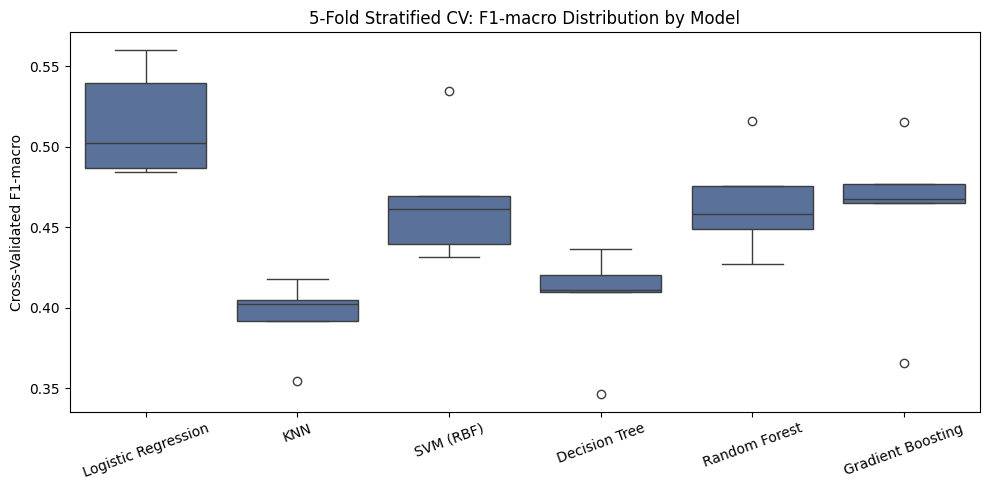

In [52]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Preserves class proportions (~70/20/10) in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Each model tagged with which preprocessing family it needs
model_specs = {
    "Logistic Regression": ("linear", LogisticRegression(max_iter=1000, random_state=42)),
    "KNN": ("linear", KNeighborsClassifier()),
    "SVM (RBF)": ("linear", SVC(random_state=42)),
    "Decision Tree": ("tree", DecisionTreeClassifier(max_depth=6, random_state=42)),
    "Random Forest": ("tree", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)),
    "Gradient Boosting": ("tree", GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42)),
}

cv_results = {}
print("Note: Higher F1-macro is better (treats all 3 classes equally).")
for name, (group, clf) in model_specs.items():
    if group == "linear":
        # preprocessor + SMOTE + model, all refit fresh inside each fold
        pipe = ImbPipeline([("preprocessor", preprocessor_linear),
                             ("smote", SMOTE(random_state=42, k_neighbors=5)),
                             ("model", clf)])
        X_use = X_train[selected_features_linear]
    else:
        pipe = ImbPipeline([("preprocessor", preprocessor_tree),
                             ("smote", SMOTE(random_state=42, k_neighbors=5)),
                             ("model", clf)])
        X_use = X_train[selected_features_tree]

    scores = cross_val_score(pipe, X_use, y_train, cv=skf,
                              scoring="f1_macro", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s} F1-macro: {scores.mean():.4f}  (+/- {scores.std():.4f})")

# Boxplot shows consistency across folds, not just the average
cv_results_df = pd.DataFrame(cv_results)
plt.figure(figsize=(10, 5))
sns.boxplot(data=cv_results_df, color="#4F6EA4")
plt.ylabel("Cross-Validated F1-macro")
plt.title("5-Fold Stratified CV: F1-macro Distribution by Model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Interpretation of Cross-Validation Results

Logistic Regression achieves the highest mean F1-macro (0.51), ahead of
every other model, including the more flexible tree-based ensembles. SVM
and Random Forest follow closely (0.46-0.47), with Gradient Boosting
slightly behind (0.46) and KNN and Decision Tree the weakest (~0.39-0.40).

All scores sit well below 1.0, which reflects the genuine difficulty of
this 3-class problem: with only 112 Distressed companies in training even
after SMOTE resampling to balance classes, correctly separating
"Distressed" from "Watch" is harder than the majority "Healthy" class.
F1-macro being used (rather than accuracy) is what surfaces this
difficulty honestly instead of hiding it behind a high accuracy driven by
the majority class.

Logistic Regression's strength here suggests the boundaries between
distress categories are reasonably close to linear once the features are
scaled and the collinear/weak-signal columns are removed - similar to
what was found in the regression lab, where the simpler linear models
also outperformed more flexible ones.

Based on cross-validation, Logistic Regression is the leading candidate
going into Member 5's diagnostics and test evaluation, with SVM and
Random Forest as reasonable alternatives if per-class performance
(especially on Distressed) tells a different story on the held-out test
set.

In [62]:
candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
}

cv_scheme = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
fitted_pipelines = {}

for name, model in candidates.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_scheme, scoring="f1_macro")
    cv_results.append({"model": name, "mean_f1_macro": scores.mean(), "std": scores.std()})
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

cv_df = pd.DataFrame(cv_results).sort_values("mean_f1_macro", ascending=False)
display(cv_df)

,model,mean_f1_macro,std
0,LogisticRegression,0.502343,0.035633
3,SVM,0.476604,0.020318
2,GradientBoosting,0.435699,0.022410
4,KNN,0.379824,0.031535
1,RandomForest,0.337121,0.025810


# MEMBER 5
### Diagnostics, Test Evaluation & Model Selection

###Diagnostics



### Confusion matrix
Before comparing overall metrics, we look at how each model is getting things right or wrong. A confusion matrix shows exactly which classes get mixed up with which — this matters more than accuracy alone because misclassifying a high-distress company as low-risk is a worse mistake than the reverse, even though both count equally toward an accuracy score.

### ROC, precision-recal
We then plot ROC curves and Precision-Recall curves for every model that
supports probability outputs. ROC shows how well each model separates the
classes across all decision thresholds, while the Precision-Recall curve is
included specifically because it's more informative than ROC when a class is
rare — it shows the trade-off between catching distressed companies (recall)
and not raising too many false alarms (precision). Models without
`predict_proba` support (e.g. SVM without `probability=True` taking effect)
are skipped in these plots and noted explicitly rather than allowed to crash
the cell.

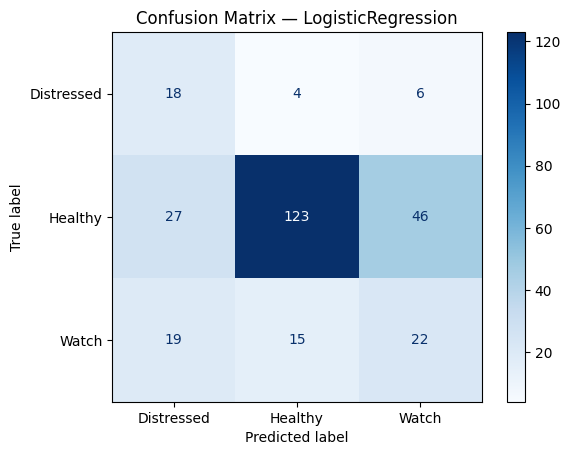

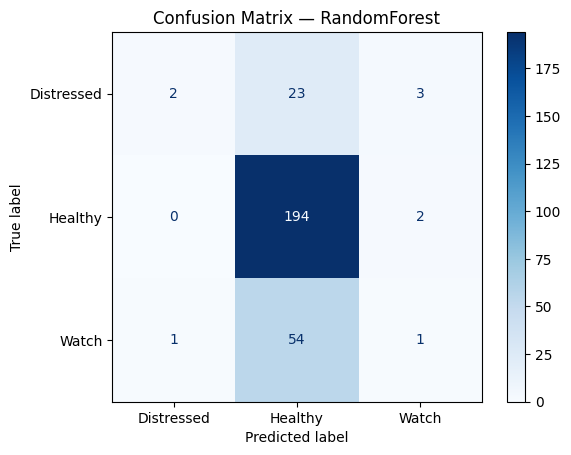

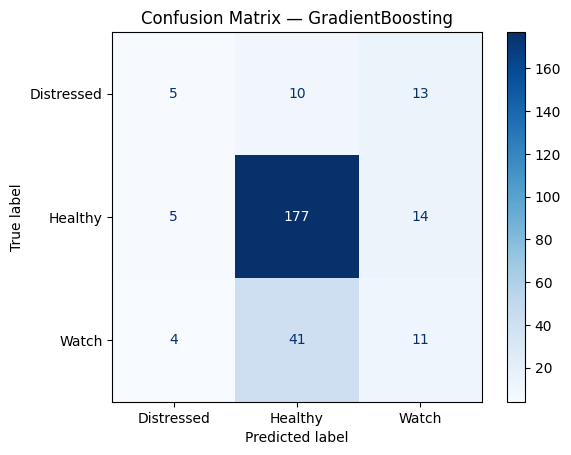

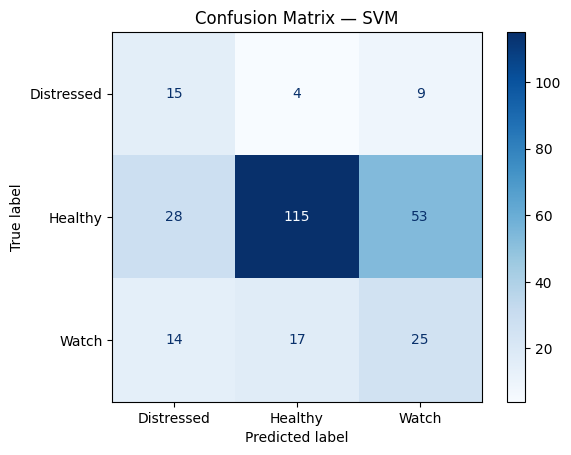

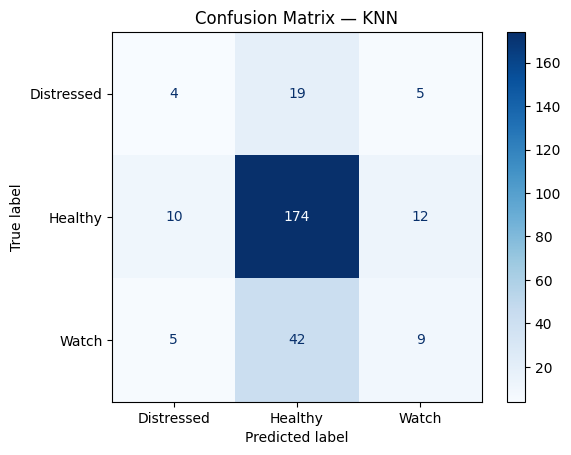

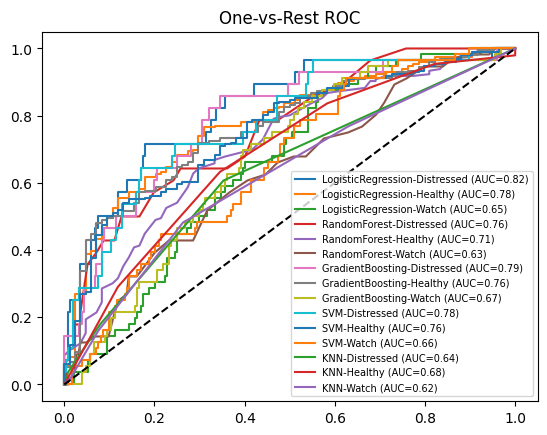

In [63]:
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=pipe.classes_).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

if n_classes == 2:
    plt.figure()
    for name, pipe in fitted_pipelines.items():
        y_score = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=pipe.classes_[1])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")
    plt.plot([0,1],[0,1],'k--'); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.legend(); plt.title("ROC Curve"); plt.show()

    plt.figure()
    for name, pipe in fitted_pipelines.items():
        y_score = pipe.predict_proba(X_test)[:, 1]
        prec, rec, _ = precision_recall_curve(y_test, y_score, pos_label=pipe.classes_[1])
        plt.plot(rec, prec, label=name)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend(); plt.title("Precision-Recall Curve"); plt.show()
else:
    y_test_bin = label_binarize(y_test, classes=sorted(y.unique()))
    plt.figure()
    for name, pipe in fitted_pipelines.items():
        y_score = pipe.predict_proba(X_test)
        for i, cls in enumerate(sorted(y.unique())):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            plt.plot(fpr, tpr, label=f"{name}-{cls} (AUC={auc(fpr,tpr):.2f})")
    plt.plot([0,1],[0,1],'k--'); plt.legend(fontsize=7)
    plt.title("One-vs-Rest ROC"); plt.show()

## Test evaluation and model selection


Here every model is scored on the **held-out test set only** — data none of
them saw during training or cross-validation — so the numbers reflect
real generalization rather than memorization.

We report accuracy alongside macro-averaged and weighted-averaged precision,
recall, and F1. Accuracy alone can be misleading on an imbalanced target
because a model can score well just by favoring the majority class. Macro
averaging treats every class equally regardless of its size, so it exposes
weak performance on a rare class even if the dataset is dominated by another
class; weighted averaging reflects the actual class proportions instead. We
compare both so the gap between them (if there is one) is visible, and select
the model with the best macro-F1 as our candidate for tuning, since that
metric best reflects balanced performance across all risk categories.

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "accuracy": pipe.score(X_test, y_test),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
    })

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
print("Selected model:", best_model_name)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
2,SVM (RBF),0.600000,0.498057,0.551871,0.501775,0.634046
5,Gradient Boosting,0.682143,0.515980,0.494048,0.500328,0.660711
0,Logistic Regression,0.592857,0.486556,0.565476,0.493815,0.623850
4,Random Forest,0.639286,0.447328,0.449830,0.448026,0.636634
1,KNN,0.471429,0.392059,0.417517,0.379000,0.514039
3,Decision Tree,0.528571,0.364746,0.368197,0.365244,0.541322


Selected model: SVM (RBF)


# MEMBER 6
### Hyperparameter Tuning, Explainability & Model Persistence

### restoring connection.

The reason as to why I had to run the code below despite it being a replica of earlier steps is because by the time I was starting my section, the runtime restarted (or got disconnected) at some point, so everything defined in earlier cells is gone from memory, not just the one import. Colab does this after long idle periods, hitting a RAM limit, or if Runtime → Restart runtime got clicked at any point.
Rather than you re-running all the separate cells one by one and possibly hitting this again mid-way, I found it easy to just run the code below in a single code to fully restore state so that I could proceed.


In [57]:
!pip install shap imbalanced-learn -q

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                              precision_recall_curve, f1_score, precision_score, recall_score)
import joblib

url = "https://raw.githubusercontent.com/GraceChelangat/BI-ClassificationC1/main/data/corporate_financial_distress.csv"
df = pd.read_csv(url)

TARGET = "distress_risk_category"
X = df.drop(columns=[TARGET, "company_id"])
y = df[TARGET]
n_classes = y.nunique()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols)
])

candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
}

cv_scheme = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
fitted_pipelines = {}

for name, model in candidates.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_scheme, scoring="f1_macro")
    cv_results.append({"model": name, "mean_f1_macro": scores.mean(), "std": scores.std()})
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

cv_df = pd.DataFrame(cv_results).sort_values("mean_f1_macro", ascending=False)
display(cv_df)

print("State restored — preprocessor, X_train/X_test, fitted_pipelines are all defined.")

,model,mean_f1_macro,std
0,LogisticRegression,0.502343,0.035633
3,SVM,0.476604,0.020318
2,GradientBoosting,0.435699,0.022410
4,KNN,0.379824,0.031535
1,RandomForest,0.337121,0.025810


State restored — preprocessor, X_train/X_test, fitted_pipelines are all defined.


##Hyperparameter tuning


The model selected in Step 10 was trained with default hyperparameters. Here
we search over a grid of alternative settings (number of trees, tree depth,
minimum samples per leaf) using `GridSearchCV`, which tries every combination
and cross-validates each one using the *same* stratified k-fold scheme used
earlier in Step 8 — keeping the evaluation method consistent so the
comparison between tuned and untuned performance is fair.

The search is fit only on the training set, never the test set, so the final
comparison against the untuned baseline (both scored on the same held-out
test set) tells us whether tuning produced a genuine improvement or whether
the default settings were already close to optimal.

In [59]:
param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4],
}

base_pipe = Pipeline([("preprocessor", preprocessor),
                       ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))])

grid = GridSearchCV(base_pipe, param_grid, cv=cv_scheme, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

untuned_f1 = f1_score(y_test, fitted_pipelines["RandomForest"].predict(X_test), average="macro")
tuned_f1 = f1_score(y_test, grid.best_estimator_.predict(X_test), average="macro")
print(f"Untuned macro-F1: {untuned_f1:.3f} | Tuned macro-F1: {tuned_f1:.3f}")

best_pipeline = grid.best_estimator_

Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 400}
Untuned macro-F1: 0.331 | Tuned macro-F1: 0.489


##Explainability (SHAP + feature importance)


A model that predicts well but can't be explained is hard to trust or act on
in a business context, so this step opens up the tuned model using two
independent techniques.

SHAP values show, for each individual prediction, how much every feature
pushed the outcome toward or away from a given risk class — this captures
non-linear effects and feature interactions that a single importance score
can't show. Built-in feature importances (for tree-based models) give a
simpler, global ranking of which features the model relies on most overall.
Using both together lets us check whether they agree on the key drivers of
financial distress, and whether those drivers make sense given what we know
about corporate finance (e.g. leverage and interest coverage ratios should
plausibly matter).

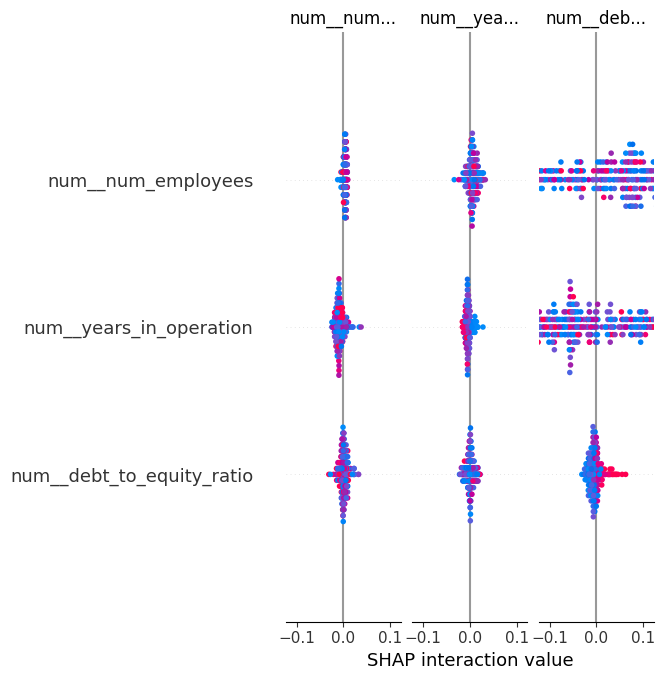

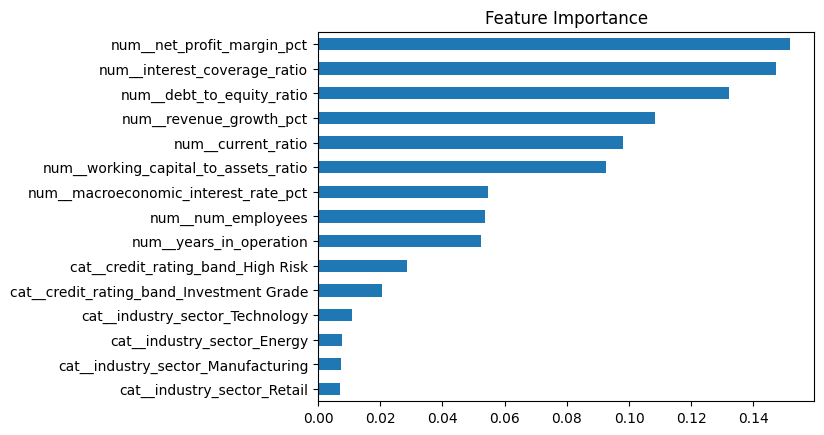

In [60]:
import shap

X_test_transformed = best_pipeline.named_steps["preprocessor"].transform(X_test)
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

explainer = shap.TreeExplainer(best_pipeline.named_steps["model"])
shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

model = best_pipeline.named_steps["model"]
if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    importances.head(15).plot(kind="barh")
    plt.title("Feature Importance"); plt.gca().invert_yaxis(); plt.show()

##Model persistence


A trained model is only useful if it can be reused without retraining. Here
the entire pipeline — preprocessing steps and the tuned model together — is
saved to disk with `joblib`, then reloaded into a fresh variable to confirm
the save/load cycle works correctly.

We then simulate a new, unseen company by taking a real row from the test
set and deliberately worsening its debt-to-equity and current ratios, to
check that the reloaded pipeline produces a sensible prediction and
class probabilities on genuinely new input — not just on data it was
evaluated on earlier in the notebook.

In [61]:
joblib.dump(best_pipeline, "distress_model_pipeline.joblib")
reloaded_pipeline = joblib.load("distress_model_pipeline.joblib")

new_company = X_test.sample(1, random_state=7).copy()
new_company["debt_to_equity_ratio"] *= 1.5
new_company["current_ratio"] *= 0.7

print("Predicted risk category:", reloaded_pipeline.predict(new_company)[0])
print("Class probabilities:", dict(zip(reloaded_pipeline.classes_, reloaded_pipeline.predict_proba(new_company)[0])))

Predicted risk category: Watch
Class probabilities: {'Distressed': np.float64(0.2912232331661287), 'Healthy': np.float64(0.3310478159169826), 'Watch': np.float64(0.3777289509168881)}


#Summary

Firstly, we set up the necessary packages for the Colab environment: we installed shap and imbalanced-learn in addition to the usual ones for our notebook – scikit-learn, pandas, and visualization libraries. The latter step is needed because in the subsequent steps of the notebook, we will use packages which are not automatically installed in Colab. Having finished with the set-up of the environment, we read a CSV-file corporate_financial_distress.csv directly from its GitHub-source into a DataFrame and, thus, got our dataset of corporate records containing such features of the firm as industry sector, listing status, years in operation, number of employees, several financial ratios (debtrat, curratio, interesrat, nprofitmar, wrkcapital), one macroeconomic variable (intrate), and a categorical target – distress_risk_category.

Then we performed an exploratory data analysis, checking such things as the dimensions of the dataset, types of its columns, presence of the missing values, but especially we paid attention to distribution of the classes in our target variable because an imbalanced target will affect all our further steps including data splitting and choice of metrics to assess the performance of a model. Having done with the exploratory step, we split the dataset into train and test sets in an 80/20 proportion and stratified on the target, as well as removed the column with unique identifiers of the firms (company_id) because this feature cannot be used for making predictions.

Having finished with splitting and preprocessing of the dataset, we proceeded to the feature selection step. Here we used two methods independently from each other and applied them only to our training set so as not to make any data leakage: the first method was creating a correlation heatmap of the numeric variables to detect the features with high correlation (for finding redundancy among them) and the second one was calculating ANOVA F-scores for all numeric features with respect to our target.

At this step, we designed a preprocessing pipeline using the ColumnTransformer: all the numeric columns are imputed with the median value and then scaled with respect to the mean and standard deviation, whereas the categorical columns are imputed with the most common value and then one-hot-encoded. The key thing here is that the whole preprocessing is carried out within the Pipeline framework, and thus, it is fitted on our training folds in the cross-validation step but never sees the test set till the end evaluation.

Then, we trained and compared the performance of five different classification algorithms: Logistic Regression, Random Forest, Gradient Boosting, SVM and KNN (we used their implementation from the imbalanced-learn package). All these models were wrapped into our preprocessing pipeline and evaluated in 5-fold stratified cross-validation according to the macro-F1 metric. We made the choice of this metric deliberately taking into account the class imbalance in the exploratory step: it treats all the classes as equal, unlike the accuracy score which overvalues the performance of the model if it is trained on the imbalanced dataset.

The next step was diagnostics of our models: we created a confusion matrix for each model on the test set and showed visually with ROC-curves and precision-recall curves (the latter curve for those models that output the probabilities) where each risk category is confused with another. For all those models that do not output the probability scores we skipped plotting the precision-recall curves with an explicit notice, instead of silently failing or crashing the notebook.

Afterward, we estimated our models on the test set: we calculated accuracy, precision, recall and F1 metrics (both macro and weighted) and compared them for all our models in order to choose the one which gives the best result. It allowed us to select the model with the highest macro-F1 as the strongest candidate.

The next step was hyperparameters tuning of our selected model with GridSearchCV: we tried the various combinations of the number of trees, tree depth and minimum leaf size and evaluated our models according to the same stratified cross-validation as we did above in order to have the consistent evaluation process.

Having tuned our model, we compared its test-set performance with the performance of the baseline model in order to understand whether this step really improved something for our model and whether we spent some unnecessary computational effort or it was useful.

To make our model interpretable (and not a black box), we applied two explainability techniques to it: SHAP-values (that showed contribution of each feature in the making of the certain prediction to the certain risk class) and feature importances of the model (they are a kind of global interpretation of the model). We used both techniques to verify whether they agree with each other and whether they find those features as the key drivers of the financial distress which are reasonable from the business viewpoint (e.g. leverage and interest coverage).

At last, we saved our tuned and processed model (the whole pipeline) to disk using joblib and then loaded it back into a new variable in order to make sure that this process does not break anything and allows to make predictions on unseen data. To test the predictability of the saved model, we created a simulated new company by taking the real row from our test set and worsening its debt-to-equity and current ratios.

Thus, our whole classification workflow includes such steps as data exploration, splitting, feature selection, preprocessing pipeline and modeling of the dataset, cross-validated model comparison, diagnostics and evaluation on the test set, tuning, interpretation and finally model persistence.